In [1]:
# Import Libraries 
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf
import datetime as dt
from datetime import date, timedelta
import plotly.graph_objects as go
import plotly.express as px

from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.arima.model import ARIMA 
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf 
from statsmodels.tsa.stattools import acf, pacf
import warnings

In [2]:
# Define the date to fatch data
today = date.today()
d1 = today.strftime("%Y-%m-%d")
end_date = d1
d2 = date.today() - timedelta(days=365)
d2 = d2.strftime("%Y-%m-%d")
start_date = d2
print(f'Your data will be from {start_date} to {end_date}')

Your data will be from 2025-05-18 to 2026-05-18


In [3]:
# Define Ticker
ticker = "GOOGL"
df = yf.download(ticker, start_date, end_date, progress=False)
df.head()

Price,Close,High,Low,Open,Volume
Ticker,GOOGL,GOOGL,GOOGL,GOOGL,GOOGL
Date,,,,,
2025-05-19,165.964508,166.064169,163.652533,163.941524,30426100
2025-05-20,163.413376,167.917762,162.337106,165.854907,46607700
2025-05-21,167.977539,172.541715,162.994817,163.124372,73416000
2025-05-22,170.279556,176.159178,170.120121,171.256181,74864400
2025-05-23,167.887848,169.372705,167.309850,168.475805,35211400


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 250 entries, 2025-05-19 to 2026-05-15
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   (Close, GOOGL)   250 non-null    float64
 1   (High, GOOGL)    250 non-null    float64
 2   (Low, GOOGL)     250 non-null    float64
 3   (Open, GOOGL)    250 non-null    float64
 4   (Volume, GOOGL)  250 non-null    int64  
dtypes: float64(4), int64(1)
memory usage: 11.7 KB


In [5]:
df.insert(0,'Date',df.index,True)   # Insert Date column from index column in to the first column 
df.reset_index(drop=True, inplace=True)  # Removing date column as index column 

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250 entries, 0 to 249
Data columns (total 6 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   (Date, )         250 non-null    datetime64[ns]
 1   (Close, GOOGL)   250 non-null    float64       
 2   (High, GOOGL)    250 non-null    float64       
 3   (Low, GOOGL)     250 non-null    float64       
 4   (Open, GOOGL)    250 non-null    float64       
 5   (Volume, GOOGL)  250 non-null    int64         
dtypes: datetime64[ns](1), float64(4), int64(1)
memory usage: 11.8 KB


In [7]:
df.describe()

Price,Date,Close,High,Low,Open,Volume
Ticker,,GOOGL,GOOGL,GOOGL,GOOGL,GOOGL
count,250,250.000000,250.000000,250.000000,250.000000,2.500000e+02
mean,2025-11-16 01:26:24,268.177458,271.017740,264.564738,267.692026,3.513166e+07
min,2025-05-19 00:00:00,163.413376,166.064169,161.635639,163.124372,1.009740e+07
25%,2025-08-18 06:00:00,202.583344,204.047551,200.298496,202.348871,2.634788e+07
50%,2025-11-13 12:00:00,283.909286,288.019393,278.960194,284.488506,3.157485e+07
75%,2026-02-16 00:00:00,315.268227,320.045954,311.695591,316.110562,3.858415e+07
max,2026-05-15 00:00:00,402.619995,403.700012,396.359985,399.920013,1.081402e+08
std,NaN,63.855810,64.510121,62.784138,63.702528,1.476937e+07


In [8]:
# Select columns
df = df[['Date','Close']]
# df['Close'] = df['Close'].squeeze() 
# df['Close'] = df['Close'].values.ravel()
df.head()

Price,Date,Close
Ticker,,GOOGL
0,2025-05-19,165.964508
1,2025-05-20,163.413376
2,2025-05-21,167.977539
3,2025-05-22,170.279556
4,2025-05-23,167.887848


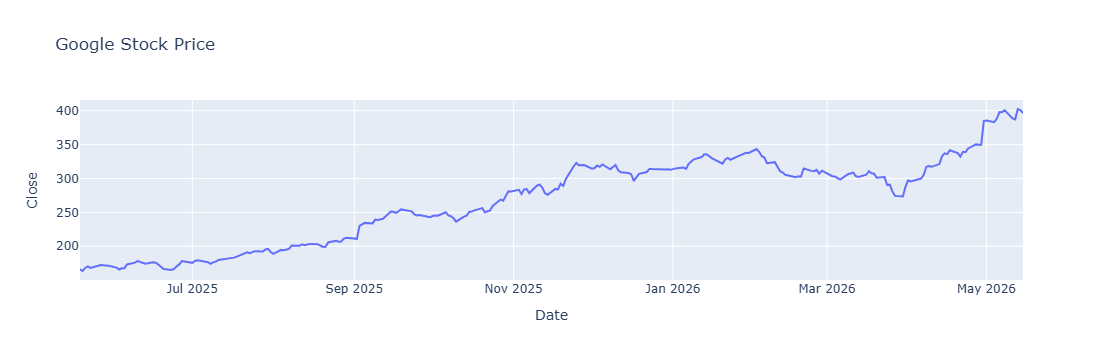

In [18]:
# Plot the data to see how it looks like using plotly 
fig = px.line(df, x='Date', y=df['Close'].squeeze(), title='Google Stock Price')
fig.update_layout(
    xaxis_title ="Date",
    yaxis_title = "Close"
)
fig.show()

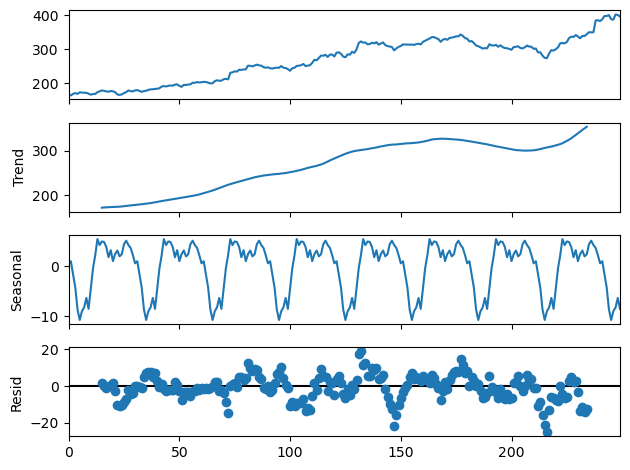

In [19]:
# Decompose the data to see trend, seasonality and noise
decompose = seasonal_decompose(df['Close'],model='additive',period=30)

decompose.plot()
plt.tight_layout()
# plt.savefig('my_plot1.png')
plt.show()

# decompose.trend
# decompose.seasonal
# decompose.resid

In [12]:
# Check stationarity 
def check_stationarity(df):
    result=adfuller(df)
    print(f"ADF Statistics: {result[0]}")
    print(f"p-value: {result[1]}")
    if result[1] < 0.05:
        print("Reject NUll hypothesis: Data is Stationary")
    else:
        print("Fail to reject NULL hypothesis: Data is Non-Stationary")

check_stationarity(df['Close'])

ADF Statistics: -0.049992352974529024
p-value: 0.954197256351688
Fail to reject NULL hypothesis: Data is Non-Stationary


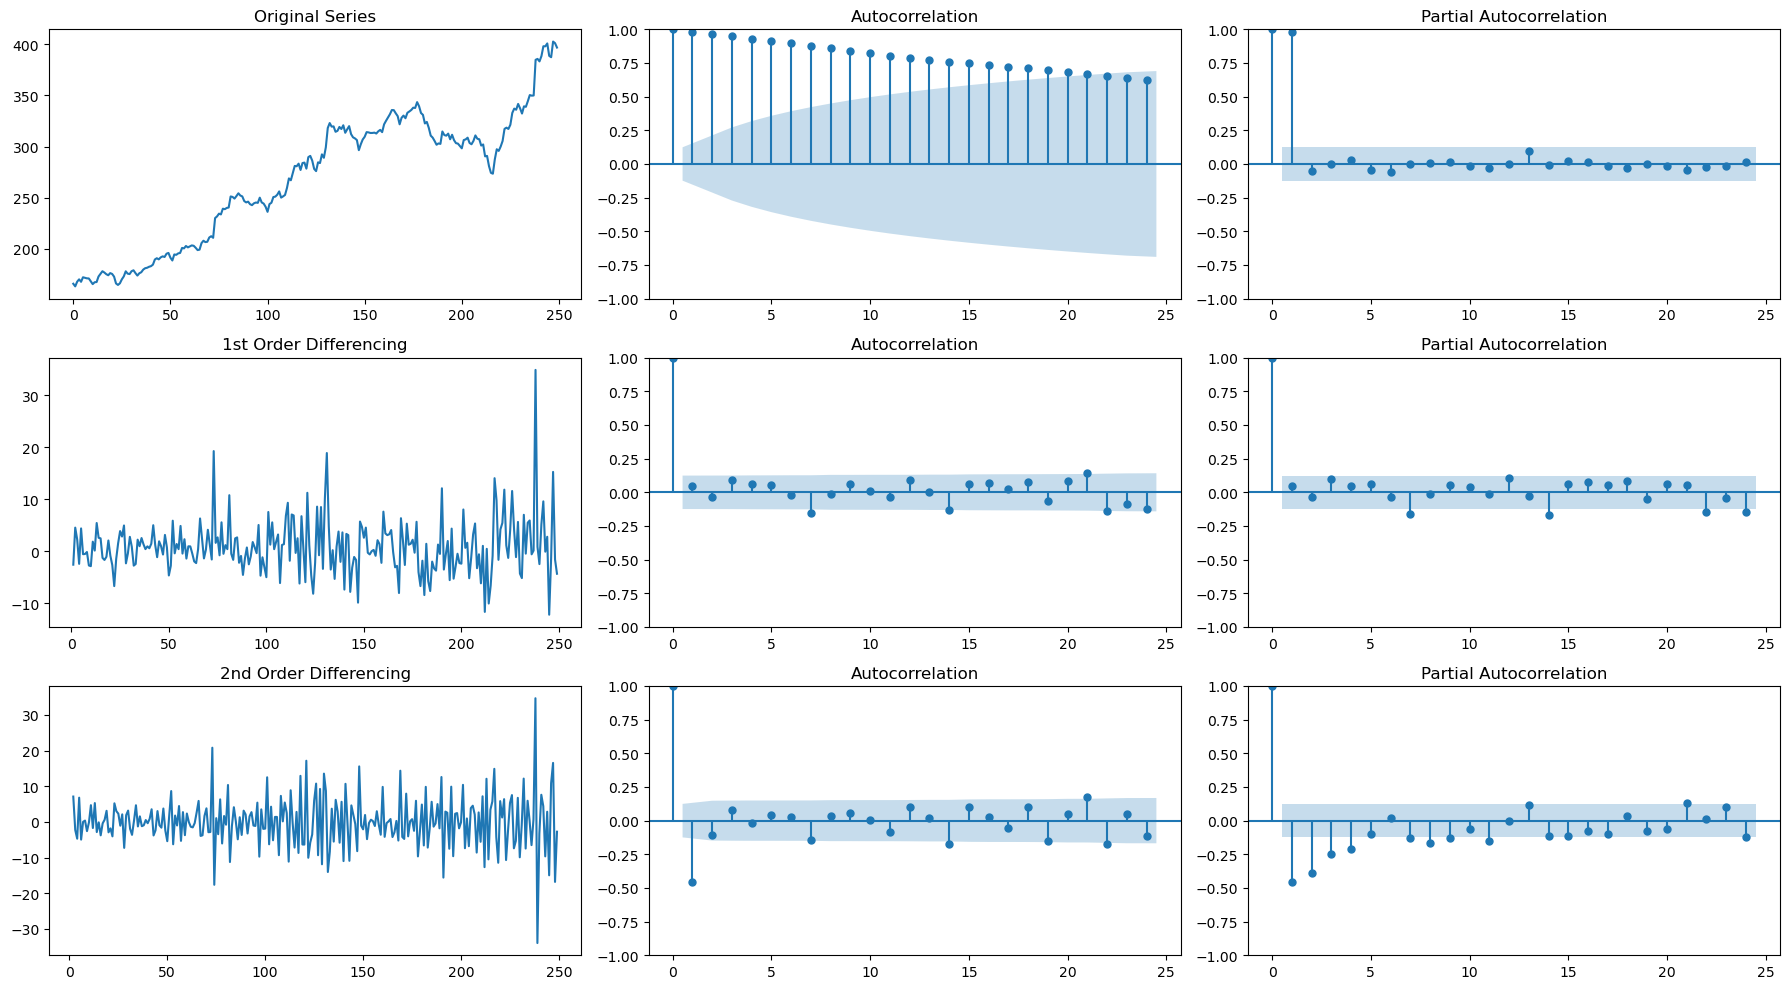

In [20]:
fig, axis = plt.subplots(3,3,figsize=(18, 10))
axis[0,0].plot(df['Close'])
axis[0,0].set_title('Original Series')
plot_acf(df['Close'],ax = axis[0,1])
plot_pacf(df['Close'],ax = axis[0,2])

axis[1,0].plot(df['Close'].diff())
axis[1,0].set_title('1st Order Differencing')
plot_acf(df['Close'].diff().dropna(),ax = axis[1,1])
plot_pacf(df['Close'].diff().dropna(),ax = axis[1,2])

axis[2,0].plot(df['Close'].diff().diff())
axis[2,0].set_title('2nd Order Differencing')
plot_acf(df['Close'].diff().diff().dropna(),ax = axis[2,1])
plot_pacf(df['Close'].diff().diff().dropna(),ax = axis[2,2])

plt.tight_layout()

plt.show()

d = 1, p=1, q=0

In [ ]:
# find the p value
# x_acf = pd.DataFrame(acf(df['Close']))
# print(f"value of lags for acf{x_acf}")

# x_pacf = pd.DataFrame(acf(df['Close']))
# print(f"value of lags for pacf{x_pacf}")

In [14]:
# Run Arima with pmdarima
from pmdarima.arima import auto_arima

model = auto_arima(df['Close'],start_p=0, start_q=0, max_p=2,max_q=2, m=12,start_P=0,seasonal=True, d=1,D=1,trace=True,error_action='ignore',surpress_warning=True)

Performing stepwise search to minimize aic
 ARIMA(0,1,0)(0,1,1)[12]             : AIC=inf, Time=1.33 sec
 ARIMA(0,1,0)(0,1,0)[12]             : AIC=1568.191, Time=0.15 sec
 ARIMA(1,1,0)(1,1,0)[12]             : AIC=1543.015, Time=0.59 sec
 ARIMA(0,1,1)(0,1,1)[12]             : AIC=inf, Time=2.42 sec
 ARIMA(1,1,0)(0,1,0)[12]             : AIC=1568.688, Time=0.18 sec
 ARIMA(1,1,0)(2,1,0)[12]             : AIC=1513.043, Time=1.71 sec
 ARIMA(1,1,0)(2,1,1)[12]             : AIC=inf, Time=7.06 sec
 ARIMA(1,1,0)(1,1,1)[12]             : AIC=inf, Time=2.99 sec
 ARIMA(0,1,0)(2,1,0)[12]             : AIC=1511.969, Time=1.84 sec
 ARIMA(0,1,0)(1,1,0)[12]             : AIC=1542.132, Time=0.40 sec
 ARIMA(0,1,0)(2,1,1)[12]             : AIC=inf, Time=6.24 sec
 ARIMA(0,1,0)(1,1,1)[12]             : AIC=inf, Time=2.76 sec
 ARIMA(0,1,1)(2,1,0)[12]             : AIC=1513.132, Time=1.36 sec
 ARIMA(1,1,1)(2,1,0)[12]             : AIC=1513.651, Time=3.37 sec
 ARIMA(0,1,0)(2,1,0)[12] intercept   : AIC=1513.3

In [15]:
print(model.summary())

                                     SARIMAX Results                                      
Dep. Variable:                                  y   No. Observations:                  250
Model:             SARIMAX(0, 1, 0)x(2, 1, 0, 12)   Log Likelihood                -752.985
Date:                            Mon, 18 May 2026   AIC                           1511.969
Time:                                    18:37:05   BIC                           1522.373
Sample:                                         0   HQIC                          1516.163
                                            - 250                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.S.L12      -0.5111      0.048    -10.567      0.000      -0.606      -0.416
ar.S.L24      -0.3928      0.060   

                               SARIMAX Results                                
Dep. Variable:                  GOOGL   No. Observations:                  250
Model:                 ARIMA(0, 1, 0)   Log Likelihood                -765.929
Date:                Mon, 18 May 2026   AIC                           1533.859
Time:                        18:48:13   BIC                           1537.376
Sample:                             0   HQIC                          1535.274
                                - 250                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
sigma2        27.4994      1.087     25.292      0.000      25.368      29.630
Ljung-Box (L1) (Q):                   0.61   Jarque-Bera (JB):               715.67
Prob(Q):                              0.43   Pr

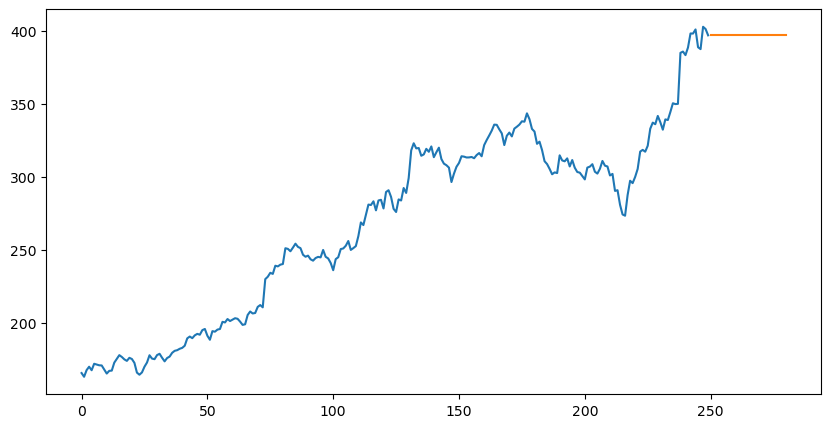

In [21]:
# Stats model and arima
p, d, q = 0, 1, 0

model = ARIMA(df['Close'], order = (p,d,q))
result = model.fit()
print(result.summary())

# predict next 30 days
forecast = result.predict(len(df['Close']),len(df['Close'])+30)
print(forecast)

# plot forecast
plt.figure(figsize=[10,5])
plt.plot(df['Close'], label='Actual')
plt.plot(forecast, label='Forecast')

plt.show()

                                     SARIMAX Results                                      
Dep. Variable:                              GOOGL   No. Observations:                  250
Model:             SARIMAX(0, 1, 0)x(2, 1, 0, 12)   Log Likelihood                -752.985
Date:                            Mon, 18 May 2026   AIC                           1511.969
Time:                                    18:48:51   BIC                           1522.373
Sample:                                         0   HQIC                          1516.163
                                            - 250                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.S.L12      -0.5111      0.048    -10.567      0.000      -0.606      -0.416
ar.S.L24      -0.3928      0.060   

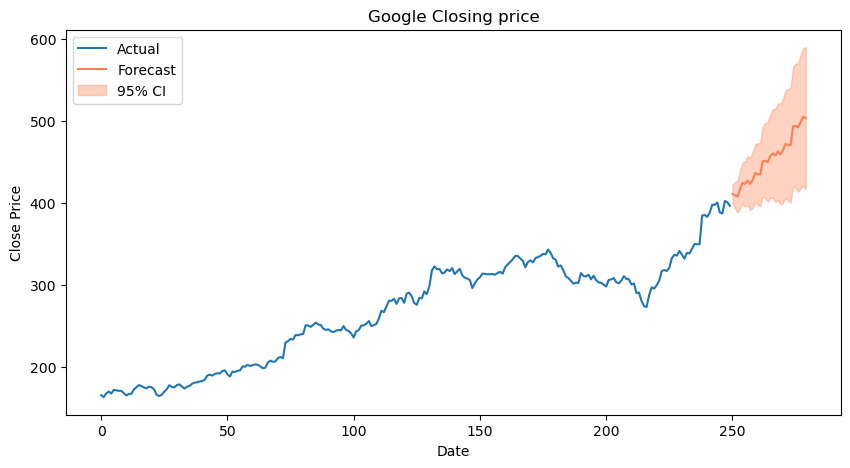

In [23]:
# Sarima Model
# SARIMAX(0, 1, 0)x(2, 1, 0, 12)
model = SARIMAX(df['Close'], order=(0,1,0), seasonal_order=(2,1,0,12))
result= model.fit()

print(result.summary())

# predict next 30 days
# forecast = result.predict(len(df['Close']),len(df['Close'])+10)
# print(forecast)

forecast = result.get_forecast(steps = 30)
pred_mean = forecast.predicted_mean
conf_int = forecast.conf_int(alpha=0.05)

# plot forecast
plt.figure(figsize=[10,5])
plt.plot(df['Close'], label='Actual')
plt.plot(pred_mean, label='Forecast', color='coral')
plt.fill_between(
    conf_int.index,
    conf_int.iloc[:, 0],
    conf_int.iloc[:, 1],
    color='coral',
    alpha=0.35,
    label='95% CI'
)
plt.xlabel("Date")
plt.ylabel('Close Price')
plt.title('Google Closing price')
plt.legend(loc= 'upper left')
# plt.savefig('my_plot4.png')
plt.show()